In [2]:
import pandas as pd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

In [3]:
v4_simu1 = xr.open_dataset("/glade/work/qingyuany/simulations/iterations/spatialtuning_v4/v4_clim_vars_1_20.nc")
v4_simu2 = xr.open_dataset("/glade/work/qingyuany/simulations/iterations/spatialtuning_v4/v4_clim_vars_21_40.nc")
v4_simu3 = xr.open_dataset("/glade/work/qingyuany/simulations/iterations/spatialtuning_v4/v4_clim_vars_41_60.nc")

sim_v4 = xr.concat([v4_simu1, v4_simu2, v4_simu3], dim = "ppe_ind")


In [4]:
parav4 = pd.read_csv("~/cam_ml/paras/v4/v4_para_scale20_zonal_original_scale.csv", index_col = False)
parav4 = parav4.iloc[:60,]
parav4.index = parav4.index + 1

In [5]:
parav4_yang = pd.read_csv("~/cam_ml/paras/v4_yang/v4_yang_scale20_zonal_original_scale.csv", index_col = False)
parav4_yang = parav4_yang.iloc[:30,]
parav4_yang.index = parav4_yang.index + 61


In [6]:
parav4 = pd.concat([parav4, parav4_yang], axis = 0)


In [7]:
ppe_zonal = pd.read_csv("/glade/work/qingyuany/camml_v6/zonal_manual_climatologies/ppe_zonal_manualselect.csv", index_col=0)
obs_zonal = pd.read_csv("/glade/work/qingyuany/camml_v6/zonal_manual_climatologies/obs_zonal_manualselect.csv", index_col=0)


In [8]:
parav4 = parav4[parav4.index.isin(ppe_zonal.index)]

parav4

,micro_mg_max_nicons,micro_mg_vtrmi_factor,micro_mg_iaccr_factor,micro_mg_berg_eff_factor,micro_mg_accre_enhan_fact,micro_mg_homog_size,micro_mg_dcs,clubb_c1,clubb_C8,clubb_c11,...,zmconv_capelmt,seasalt_emis_scale,dust_emis_fact,sol_factb_interstitial,sol_factic_interstitial,microp_aero_wsub_min,microp_aero_wsubi_min,microp_aero_wsub_scale,microp_aero_wsubi_scale,microp_aero_npccn_scale
1,4.381946e+09,2.789803,0.501023,0.119478,1.365143,0.000169,0.000320,0.924486,1.748313,0.324930,...,93.070808,0.757290,0.585022,0.946350,0.369548,0.329856,0.074237,2.193338,2.661443,0.960585
3,2.089233e+08,4.624963,0.251300,0.181944,0.288745,0.000129,0.000362,0.763723,1.670928,0.543354,...,79.081773,1.934610,0.591578,0.386810,0.707490,0.497364,0.170409,1.374155,1.506662,0.892666
4,9.490586e+09,3.014059,0.300799,0.305010,2.465816,0.000029,0.000285,0.896666,4.471800,0.708435,...,77.169813,0.865866,0.799698,0.333402,0.298639,0.091261,0.105339,4.788141,1.686467,2.205985
5,3.401681e+09,3.705172,0.402688,0.157646,2.715901,0.000126,0.000341,0.502093,4.581458,0.349532,...,56.170785,1.009777,0.705715,0.204631,0.451381,0.036898,0.191577,2.973753,4.584618,2.288246
6,3.586027e+08,3.068076,0.756834,0.141626,0.742655,0.000164,0.000257,0.814442,2.308663,0.667318,...,68.489399,1.231708,0.181719,0.582467,0.918057,0.078940,0.049163,2.622643,1.502906,2.186511
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86,8.038900e+09,4.646380,0.362950,0.349731,7.720564,0.000049,0.000371,1.444336,3.200305,0.602348,...,116.108291,1.722681,0.713848,0.184155,0.557609,0.087135,0.190349,1.207230,2.952219,1.555209
87,1.385107e+09,4.246736,0.424797,0.189261,5.631580,0.000183,0.000380,0.476958,1.120763,0.204510,...,69.260113,1.519703,0.864466,0.617295,0.288740,0.086690,0.089505,1.994792,2.009423,2.592510
88,4.789406e+09,4.254390,0.262201,0.170275,8.188741,0.000176,0.000427,0.755609,4.626478,0.321648,...,84.143568,1.765466,0.575620,0.288459,0.855079,0.153689,0.175064,2.202539,3.583207,0.696545
89,5.927975e+09,4.710758,0.682748,0.197095,3.494720,0.000168,0.000544,0.545305,4.907264,0.689263,...,102.532926,2.225436,0.872731,0.858277,0.151385,0.148672,0.191885,1.312410,1.487821,2.286606


In [21]:
ppe_zonal.corrwith(parav4.zmconv_tiedke_add).abs().sort_values(ascending = False).head(50)

PRECT_zonal_lat_-37       0.553689
SWCF_-6_-4_141_144        0.485609
PRECT_zonal_lat_-42       0.477932
PRECT_zonal_lat_-32       0.468805
PRECT_zonal_lat_42        0.458533
PRECT_zonal_lat_7         0.455428
PRECT_zonal_lat_32        0.417420
PRECT_zonal_lat_37        0.414492
PRECT_0_5_90_95           0.397201
PRECT_zonal_lat_-27       0.395637
PRECT_zonal_lat_-47       0.381993
TMQ_zonal_lat_7           0.352228
PRECT_zonal_lat_47        0.325221
TMQ_zonal_lat_-72         0.303999
TMQ_zonal_lat_-67         0.302022
TMQ_5_10_200_220          0.299492
FSNTOA_zonal_lat_-62      0.291629
PRECT_zonal_lat_27        0.285770
SWCF_zonal_lat_-62        0.280801
TMQ_5_8_135_145           0.274764
TMQ_zonal_lat_12          0.273423
TMQ_zonal_lat_-77         0.265979
PRECT_zonal_lat_12        0.265466
FSNTOA_zonal_lat_-67      0.262250
PRECT_zonal_lat_-52       0.255443
PRECT_6_10_220_240        0.255272
PRECT_zonal_lat_-22       0.244603
TMQ_zonal_lat_2           0.241221
SWCF_7_9_235_240    

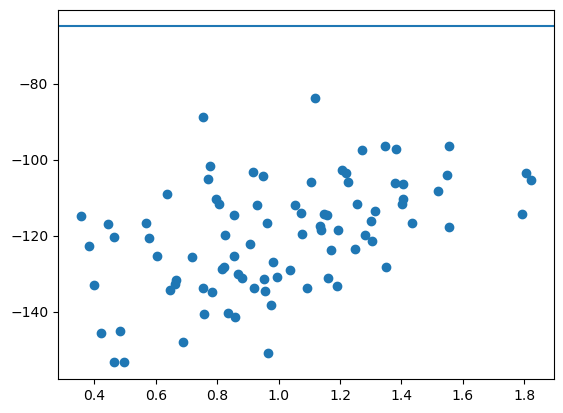

In [26]:
plt.scatter(parav4.zmconv_tiedke_add, ppe_zonal["SWCF_-6_-4_141_144"])
plt.axhline(obs_zonal.loc["SWCF_-6_-4_141_144"].values)
#plt.axhline(obs_zonal.loc["PRECT_zonal_lat_-37"].values/ (3600 * 1000 * 24))

In [8]:
parav4_norm = (parav4-parav4.min())/(parav4.max() - parav4.min())

In [9]:
emu_para = xr.open_dataset("/glade/work/qingyuany/camml_v6/parameter_samples/para_samples.nc").to_dataframe()

In [10]:
ppe_zonal.head()

,SWCF_zonal_lat_-82,SWCF_zonal_lat_-77,SWCF_zonal_lat_-72,SWCF_zonal_lat_-67,SWCF_zonal_lat_-62,SWCF_zonal_lat_-57,SWCF_zonal_lat_-52,SWCF_zonal_lat_-47,SWCF_zonal_lat_-42,SWCF_zonal_lat_-37,...,LWCF_5_10_200_220,TMQ_5_10_200_220,TMQ_5_8_135_145,TMQ_10_15_90_95,FLUT_6_8_275_280,FLUT_0_5_85_90,PRECT_6_8_275_280,PRECT_6_10_220_240,PRECT_0_5_90_95,PRECT_-1_1_113_115
ppe_ind,,,,,,,,,,,,,,,,,,,,,
1,-1.775323,-3.677040,-8.188253,-26.007094,-55.478150,-73.107625,-77.024634,-73.212884,-64.607686,-54.185431,...,42.237118,50.926451,51.155686,48.030842,188.725400,235.855198,2.144443e-07,1.291109e-07,5.737806e-08,1.112224e-07
3,-1.618221,-3.374800,-8.302124,-26.239062,-55.215606,-72.102811,-75.852205,-72.355755,-63.536108,-53.471915,...,40.278538,49.468480,47.521801,42.907259,205.532444,248.364480,2.203473e-07,1.355944e-07,6.664543e-08,1.414240e-07
4,-1.765804,-3.844527,-8.594140,-27.004102,-56.849576,-74.685015,-78.965654,-77.357821,-74.099307,-67.848767,...,42.208071,52.102258,52.861437,47.787588,209.736810,241.644955,1.721039e-07,1.397144e-07,5.880796e-08,1.355674e-07
5,-2.353393,-4.225666,-8.897521,-27.351285,-56.519404,-73.319435,-76.810730,-74.351819,-69.418165,-63.010395,...,40.124951,51.354876,54.582372,49.958684,189.795158,225.372543,1.737110e-07,1.020140e-07,5.462205e-08,1.159605e-07
6,-1.377978,-3.060643,-7.356543,-24.552219,-52.189145,-68.319704,-71.086715,-68.272482,-62.101780,-52.859389,...,31.107965,51.758989,54.698607,49.581895,220.764464,241.434916,1.176212e-07,9.157055e-08,5.267397e-08,1.196123e-07


In [57]:
var_name = "LWCF_zonal_lat_2"

In [58]:
yppe = ppe_zonal[var_name]
yobs = obs_zonal.loc[var_name]

In [59]:
yemu = pd.read_csv("/glade/work/qingyuany/camml_v6/emulated_vars/gp_mean_" + var_name + ".csv", index_col=0)
yemu_std = pd.read_csv("/glade/work/qingyuany/camml_v6/emulated_vars/gp_std_" + var_name + ".csv", index_col=0)

yemu = yemu * yppe.std() + yppe.mean()
yemu_std = yemu_std * yppe.std() 


In [60]:
parav4.corrwith(yppe).abs().sort_values(ascending = False)

microp_aero_wsubi_scale      0.674950
zmconv_ke                    0.263270
clubb_c14                    0.238765
cldfrc_dp1                   0.237354
microp_aero_wsub_min         0.192556
clubb_c2rt                   0.191277
zmconv_dmpdz                 0.186466
sol_factic_interstitial      0.142211
clubb_C8                     0.138228
seasalt_emis_scale           0.133688
clubb_c1                     0.132918
micro_mg_vtrmi_factor        0.129253
clubb_beta                   0.124426
microp_aero_wsubi_min        0.117941
dust_emis_fact               0.110822
cldfrc_dp2                   0.097199
micro_mg_homog_size          0.095948
micro_mg_iaccr_factor        0.091536
micro_mg_dcs                 0.090464
micro_mg_max_nicons          0.087638
clubb_gamma_coef             0.085142
microp_aero_npccn_scale      0.082539
sol_factb_interstitial       0.080154
clubb_c_K10                  0.076132
micro_mg_accre_enhan_fact    0.072513
zmconv_c0_lnd                0.070540
clubb_c11   

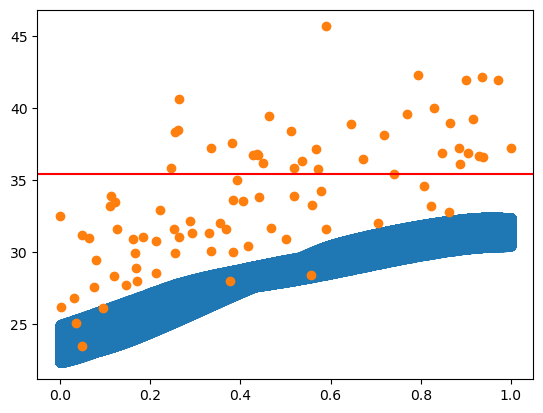

In [63]:
plt.scatter(emu_para.microp_aero_wsubi_scale, yemu  - 1.8 * yemu_std)
plt.scatter(parav4_norm.microp_aero_wsubi_scale, ppe_zonal[var_name])
#plt.axhline(yobs.values/(24 * 3600 * 1000), color = "red")
plt.axhline(yobs.values, color = "red")